In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# creating database connection
conn = sqlite3.connect('inventory.db')

In [4]:
df = pd.read_sql_query("select * from vendor_sales_summary", conn)

In [5]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,60320,1584606.40,9578.0,344712.22,64889.97,17598.14,68601.68,-1239894.18,-359.689651,0.158786,0.217538
1,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,96073,1553500.41,20226.0,444810.74,43304.31,37163.76,257032.07,-1108689.67,-249.249753,0.210527,0.286328
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,62385,1446708.15,9203.0,275162.97,52289.50,16909.12,144929.24,-1171545.18,-425.764114,0.147519,0.190199
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,75385,1375022.40,11189.0,288135.11,48202.30,20557.97,123780.22,-1086887.29,-377.214457,0.148425,0.209549
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,58783,1286759.87,11883.0,357759.17,52774.51,21833.58,257032.07,-929000.70,-259.672086,0.202150,0.278031


Exploratory Data Analysis

Previously, we examined the different tables in the database to identify key variables, understand their relationships, and decide which tables should be used for the final analysis.

In this stage of EDA, we analyze the resulting summary table to understand the distribution of each column. This helps identify data patterns, detect anomalies, and ensure data quality before proceeding with further analysis.

In [6]:
##Summary Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8512.0,1.015346e+04,17718.122212,2.00,3664.000000,7153.000000,9552.000000,1.733570e+05
Brand,8512.0,1.760026e+04,13004.702546,58.00,5297.750000,17432.500000,24988.000000,9.063100e+04
PurchasePrice,8512.0,2.188977e+01,105.829821,0.36,6.800000,10.270000,18.240000,5.681810e+03
ActualPrice,8512.0,3.218842e+01,144.210224,0.49,10.990000,15.990000,26.990000,7.499990e+03
Volume,8512.0,8.548756e+02,617.982459,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,8512.0,1.691844e+03,5496.001551,1.00,24.000000,231.500000,1195.000000,1.607350e+05
TotalPurchaseDollars,8512.0,1.578656e+04,56938.194190,0.71,344.880000,2840.535000,12601.875000,1.584606e+06
TotalSalesQuantity,8512.0,2.872162e+02,967.741069,0.00,3.000000,34.000000,200.000000,2.854400e+04
TotalSalesDollars,8512.0,3.873112e+03,13541.331564,0.00,59.940000,649.745000,3129.827500,4.448107e+05
TotalSalesPrice,8512.0,1.890345e+03,4290.868376,0.00,22.692500,363.675000,1831.792500,6.488997e+04


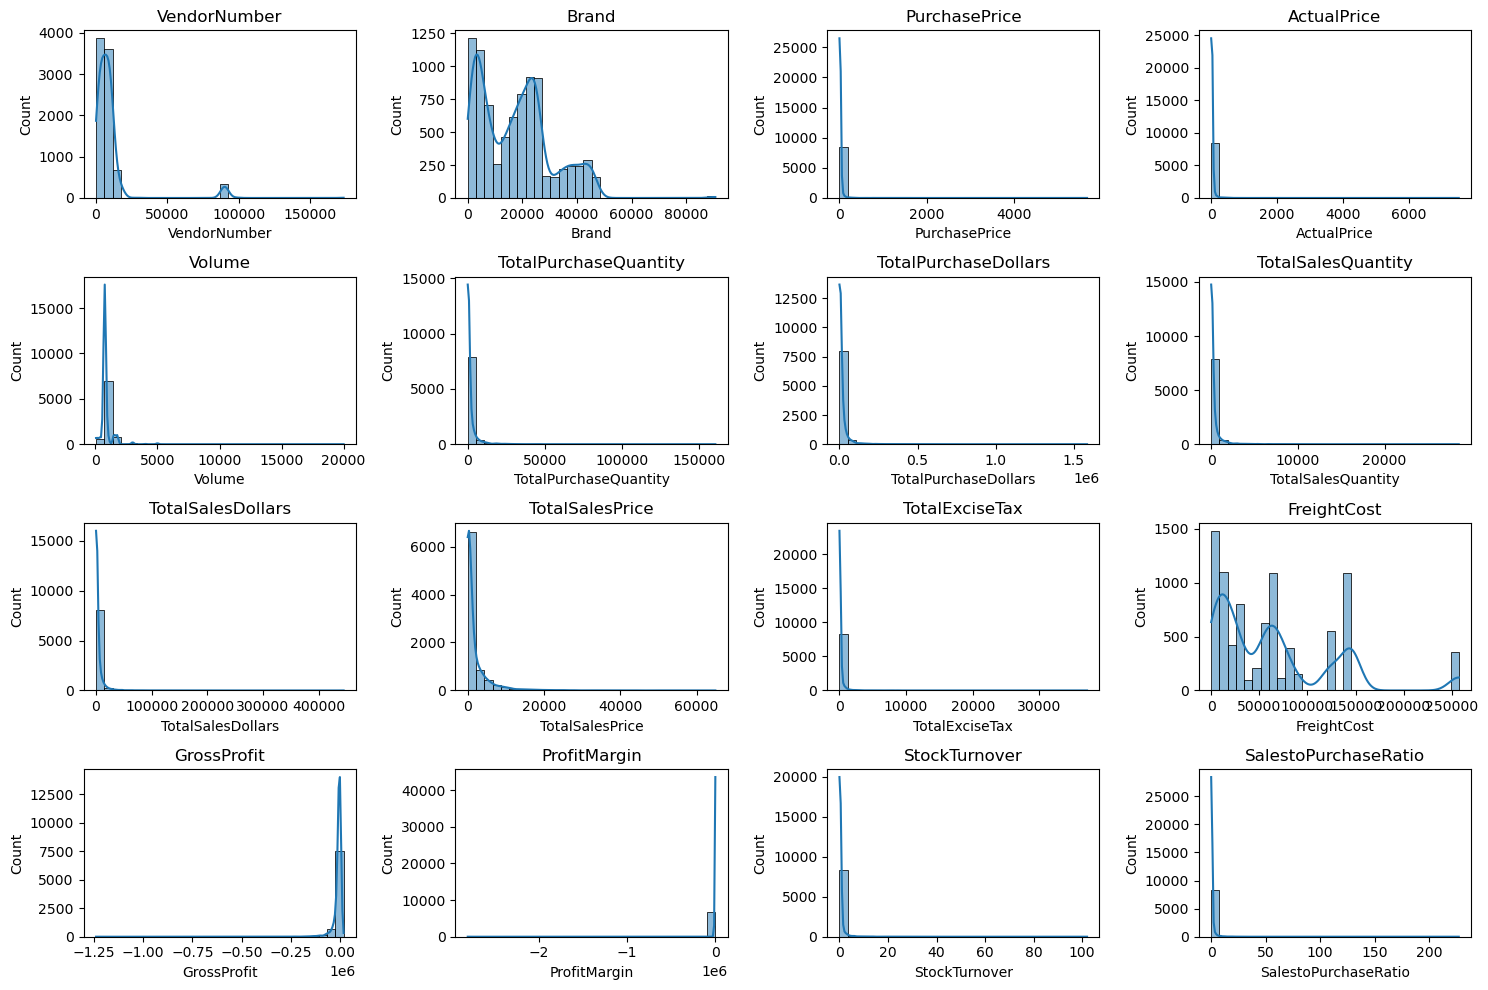

In [8]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

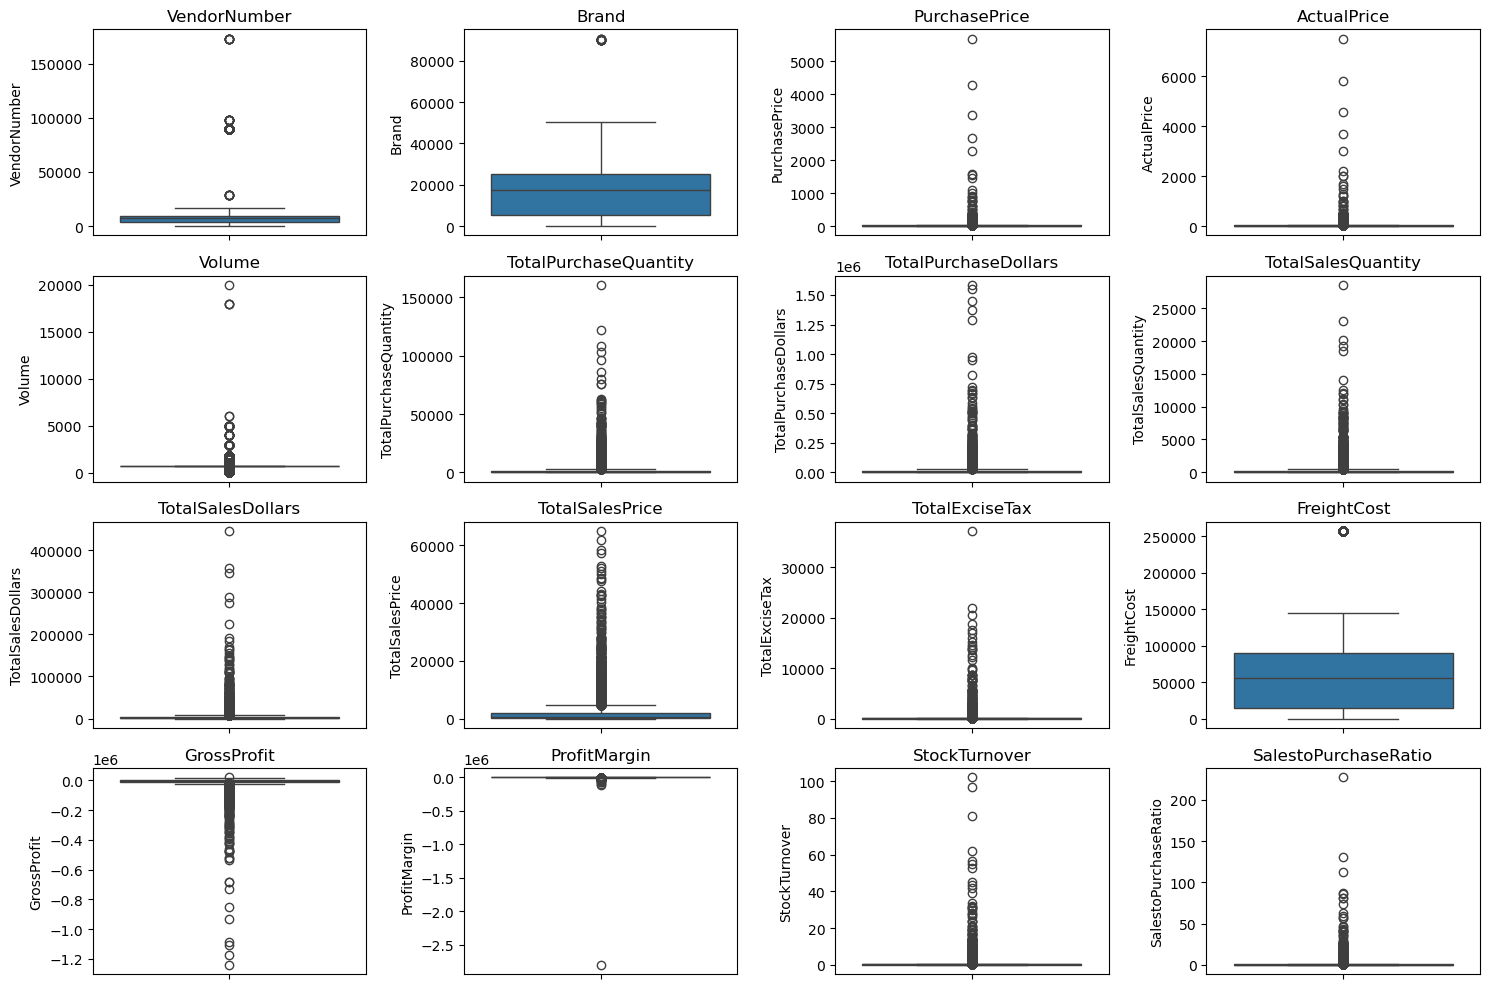

In [9]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Summary Statistics Insights
Negative & Zero Values

.Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

.Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.

.Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations

.Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

.Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

.Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock.

In [10]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0
""", conn)

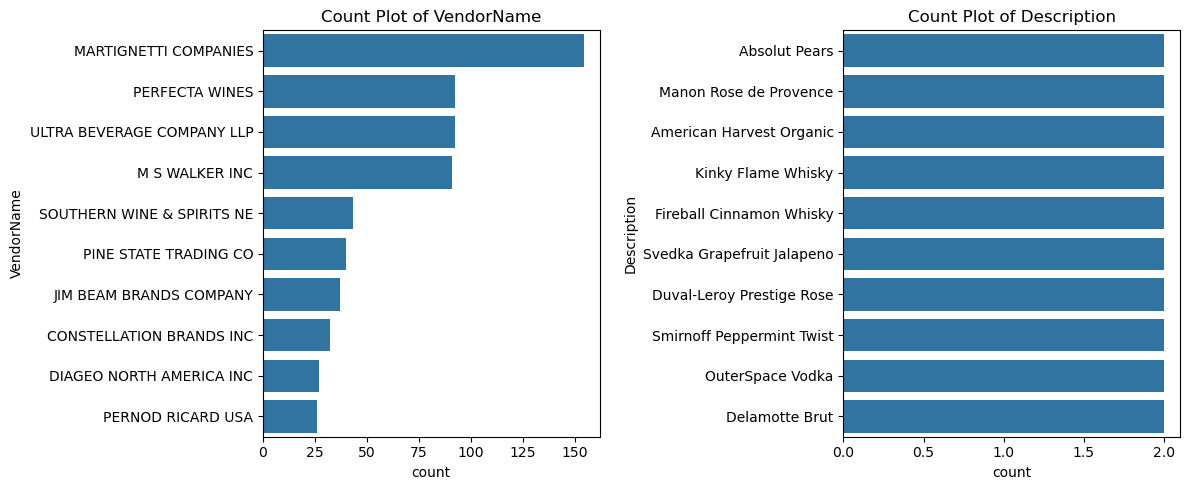

In [11]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

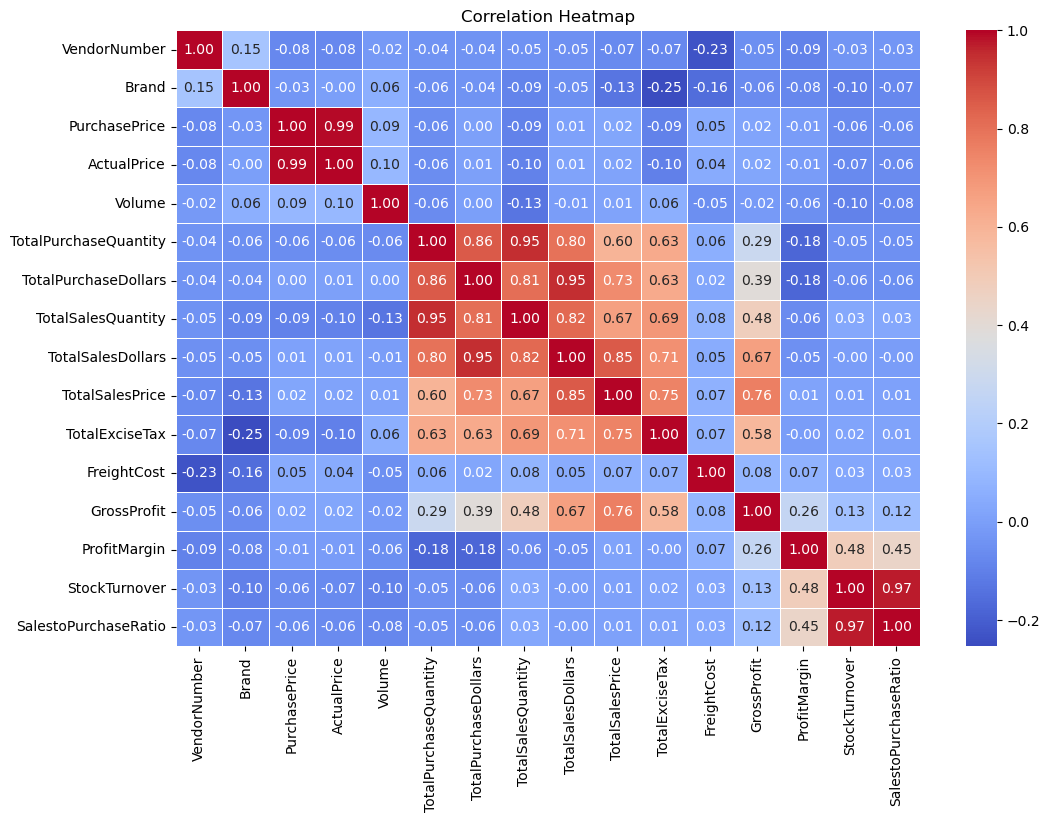

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Correlation Insights

PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability


Data Analysis

Identify brands that needs promotional or Pricing Adjustments which exhibit lower sales performance
but higher profit margins.

In [13]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [14]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
low_sales_threshold

np.float64(117.98)

In [16]:

high_margin_threshold

np.float64(86.42455041969913)

In [17]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
915,Tracia Syrah,44.94,88.495772
64,Bacardi Oakheart Spiced Trav,59.94,87.554221
272,Chicken & Turkey Cotes du Rh,59.94,90.990991
349,Dr McGillicuddy's Apple Pie,62.72,96.269133
837,St Elder Elderflower Liqueur,66.33,91.436756
46,Aresti Pnt Nr Curico Vly,74.85,95.617902
324,DeKuyper Buttershots Trav,76.93,90.718835
900,Three Olives Grape Vodka,80.19,99.114603
838,St Germain Liqueur,89.94,87.658439
699,Piehole Apple Pie,98.01,95.592287


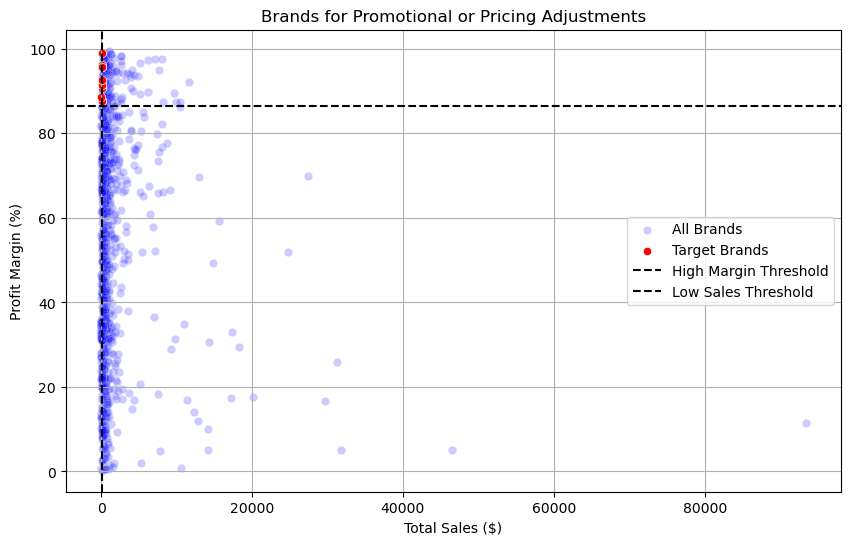

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',
                color="blue", label="All Brands", alpha = 0.2)

sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',
                color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black',
            label="High Margin Threshold")

plt.axvline(low_sales_threshold, linestyle='--', color='black',
            label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [19]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [20]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors

VendorName
MARTIGNETTI COMPANIES         243980.10
CONSTELLATION BRANDS INC      180305.21
ULTRA BEVERAGE COMPANY LLP    148726.20
M S WALKER INC                117693.77
PERFECTA WINES                114277.24
BACARDI USA INC                61602.49
BROWN-FORMAN CORP              46884.09
DIAGEO NORTH AMERICA INC       42011.94
JIM BEAM BRANDS COMPANY        41429.49
SOUTHERN WINE & SPIRITS NE     40497.96
Name: TotalSalesDollars, dtype: float64

In [21]:
top_brands

Description
Simi Chard                      93369.42
Simi Cab Svgn                   46523.13
Banfi Centine Mntcln Tscna      31728.09
Rodney Strong Cab Svgn          31245.60
Ch La Rousseliere St Estephe    29698.02
Buehler Chard RRV               27397.25
Madison's Ranch Cab Svgn        24797.91
Rodney Strong Chard             20080.57
Cava Mistinguett Brut           18241.17
Bacardi Twin Pack 2/750mls      17331.33
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands.apply(lambda x :format_dollars(x))

Description
Simi Chard                      93.37K
Simi Cab Svgn                   46.52K
Banfi Centine Mntcln Tscna      31.73K
Rodney Strong Cab Svgn          31.25K
Ch La Rousseliere St Estephe    29.70K
Buehler Chard RRV               27.40K
Madison's Ranch Cab Svgn        24.80K
Rodney Strong Chard             20.08K
Cava Mistinguett Brut           18.24K
Bacardi Twin Pack 2/750mls      17.33K
Name: TotalSalesDollars, dtype: object

In [23]:
top_vendors.apply(lambda x :format_dollars(x))

VendorName
MARTIGNETTI COMPANIES         243.98K
CONSTELLATION BRANDS INC      180.31K
ULTRA BEVERAGE COMPANY LLP    148.73K
M S WALKER INC                117.69K
PERFECTA WINES                114.28K
BACARDI USA INC                61.60K
BROWN-FORMAN CORP              46.88K
DIAGEO NORTH AMERICA INC       42.01K
JIM BEAM BRANDS COMPANY        41.43K
SOUTHERN WINE & SPIRITS NE     40.50K
Name: TotalSalesDollars, dtype: object

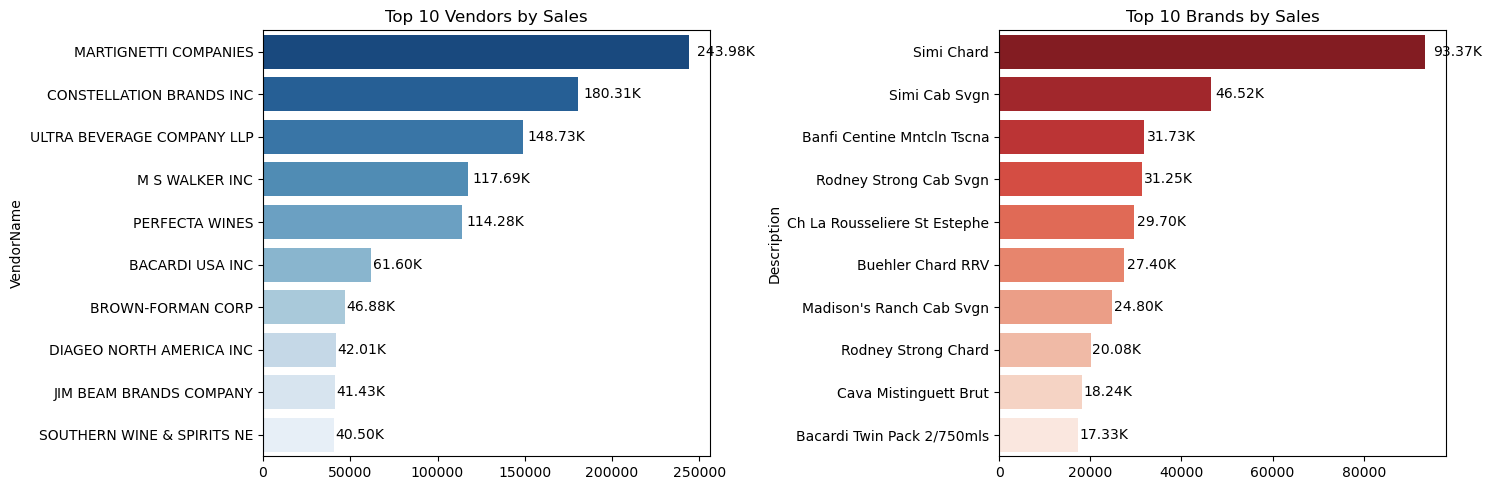

In [24]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dollars?

In [25]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(72, 4)

In [26]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ALISA CARR BEVERAGES,2409.40,2871.96,5281.36
1,ATLANTIC IMPORTING COMPANY,620.40,129.35,749.75
2,BACARDI USA INC,30939.14,30663.35,61602.49
3,BANFI PRODUCTS CORP,33925.17,3667.98,37593.15
4,BROWN-FORMAN CORP,9493.91,37390.18,46884.09
...,...,...,...,...
67,VRANKEN AMERICA,315.76,344.13,659.89
68,WEIN BAUER INC,36.56,5.38,41.94
69,WESTERN SPIRITS BEVERAGE CO,190.44,629.15,819.59
70,WILLIAM GRANT & SONS INC,2430.04,3013.57,5443.61


In [27]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [28]:
round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
9,CONSTELLATION BRANDS INC,155184.04,25121.17,180305.21,0.21
33,MARTIGNETTI COMPANIES,106115.65,137864.45,243980.10,0.14
42,PERFECTA WINES,65884.50,48392.74,114277.24,0.09
63,ULTRA BEVERAGE COMPANY LLP,56969.42,91756.78,148726.20,0.08
31,M S WALKER INC,46582.51,71111.26,117693.77,0.06
...,...,...,...,...,...
32,MARSALLE COMPANY,78.78,1378.41,1457.19,0.00
20,FANTASY FINE WINES CORP,64.32,15.58,79.90,0.00
6,CAPSTONE INTERNATIONAL,54.64,173.24,227.88,0.00
68,WEIN BAUER INC,36.56,5.38,41.94,0.00


In [29]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ALISA CARR BEVERAGES,2.41K,2.87K,5.28K,0.003289
1,ATLANTIC IMPORTING COMPANY,620.4,129.35000000000002,749.75,0.000847
2,BACARDI USA INC,30.94K,30.66K,61.60K,0.042240
3,BANFI PRODUCTS CORP,33.93K,3.67K,37.59K,0.046317
4,BROWN-FORMAN CORP,9.49K,37.39K,46.88K,0.012962
5,CAMPARI AMERICA,2.01K,2.00K,4.01K,0.002746
6,CAPSTONE INTERNATIONAL,54.64,173.24,227.88,0.000075
7,CASTLE BRANDS CORP.,862.4399999999999,850.94,1.71K,0.001177
8,CHARLES JACQUIN ET CIE INC,91.08,635.88,726.96,0.000124
9,CONSTELLATION BRANDS INC,155.18K,25.12K,180.31K,0.211867


In [30]:
top_vendors['PurchaseContribution%'].sum()

np.float64(0.3216442671812866)

In [31]:
top_vendors.columns

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%'],
      dtype='object')

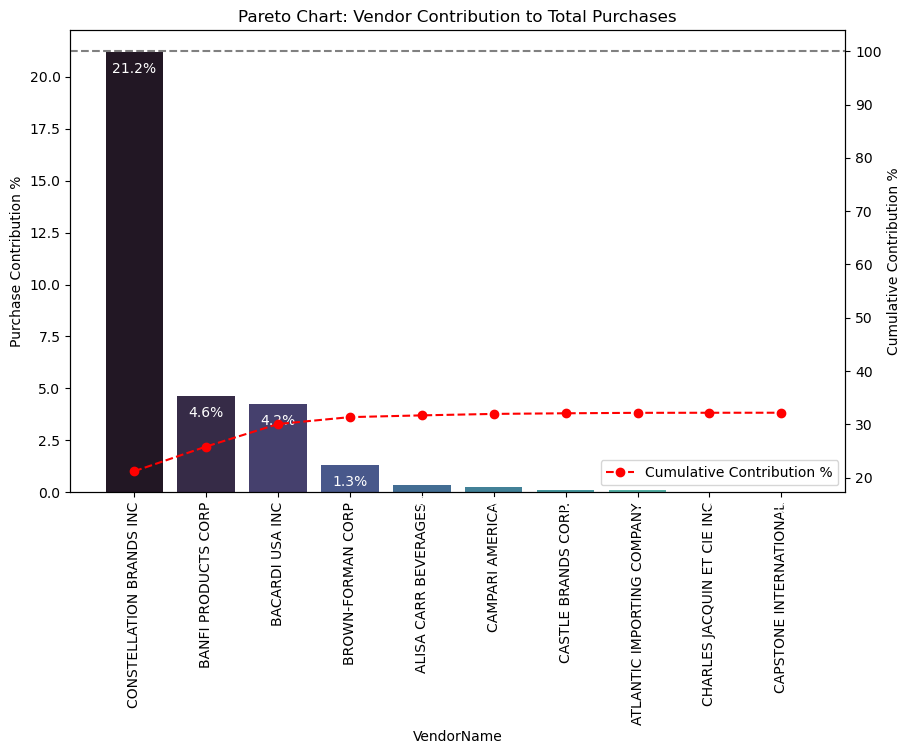

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# convert to percentage
top_vendors['PurchaseContribution%'] = top_vendors['PurchaseContribution%'] * 100

# sort vendors
top_vendors = top_vendors.sort_values(
    by='PurchaseContribution%',
    ascending=False
)

# cumulative contribution
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

# bar labels
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1, f"{value:.1f}%", ha='center', color='white')

# cumulative line
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel("Purchase Contribution %")
ax2.set_ylabel("Cumulative Contribution %")

ax1.set_title("Pareto Chart: Vendor Contribution to Total Purchases")

ax2.axhline(y=100, color='gray', linestyle='dashed')

ax2.legend()

plt.show()

How much of total procurement is dependent on top vendors?


In [33]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")


Total Purchase Contribution of top 10 vendors is 32.16 %


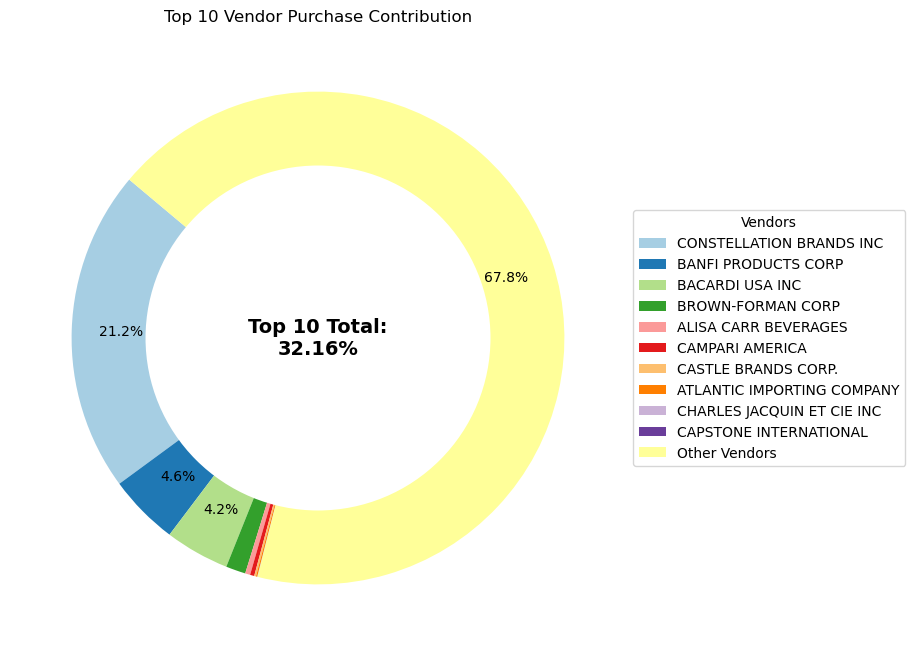

In [34]:
import matplotlib.pyplot as plt

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Add other vendors
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=None,                 # remove crowded labels
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',  # show only >3%
    startangle=140,
    pctdistance=0.80,
    colors=plt.cm.Paired.colors
)

# Donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Center text
plt.text(
    0,0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

# Legend instead of labels
ax.legend(wedges, vendors,
          title="Vendors",
          loc="center left",
          bbox_to_anchor=(1,0.5))

plt.title("Top 10 Vendor Purchase Contribution")

plt.show()

Does purchasing in bulk reduce the unit price ,and what is the optimal purchase volume for cost savings?

In [35]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [36]:
df['UnitPurchasePrice']

0       7.38
1      10.52
2       5.26
3      99.33
4      10.32
       ...  
977     3.28
978     1.32
979     0.39
980     2.25
981     0.71
Name: UnitPurchasePrice, Length: 982, dtype: float64

In [37]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["Small","Medium","Large"])

In [38]:
df[["OrderSize","TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Large,11199
1,Large,4194
2,Large,5723
3,Large,249
4,Large,2241
...,...,...
977,Small,1
978,Small,2
979,Small,6
980,Small,1


In [39]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,35.900600
Medium,20.687564
Large,11.248938


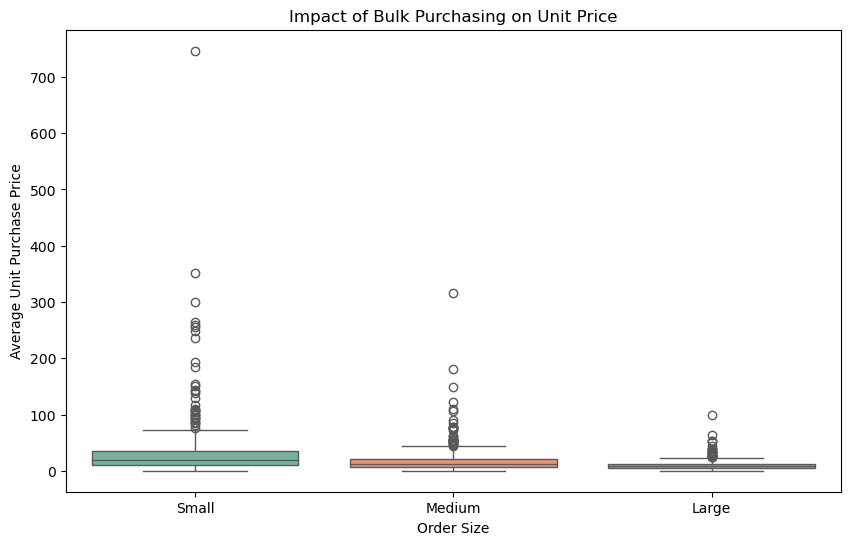

In [40]:

import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

Vendors purchasing in large order sizes receive the lowest unit purchase price (around $10.78 per unit), which can improve profit margins if inventory is managed efficiently.

There is a significant price reduction between small and large orders, with approximately a 72% decrease in unit cost as order size increases.

This indicates that bulk purchasing leads to better pricing, encouraging vendors to buy larger quantities.

Such pricing strategies help businesses increase overall sales volume, even if the per-unit revenue decreases, because larger orders compensate through scale.

Which vendors have low inventory turnover,indicating excess stock and slow-moving products?

In [41]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
PALM BAY INTERNATIONAL INC,0.666667
WILLIAM GRANT & SONS INC,0.695652
WINE GROUP INC,0.704774
TREASURY WINE ESTATES,0.705882
CONSTELLATION BRANDS INC,0.726606
BANFI PRODUCTS CORP,0.727246
STE MICHELLE WINE ESTATES,0.727273
E & J GALLO WINERY,0.730680
Russian Standard Vodka,0.730769


How much Capital is locked in unsold inventory per vendor and which vendor contribute 
the most to it?

In [42]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]


In [43]:
print("Total Unsold Capital:", format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: -250988.90000000002


In [44]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

# Format values as dollars
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)

# Top 10 vendors with highest unsold inventory
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
9,CONSTELLATION BRANDS INC,35.23K
3,BANFI PRODUCTS CORP,9.89K
62,TRINCHERO FAMILY ESTATES,3.80K
23,FREDERICK WILDMAN & SONS,3.11K
71,WINE GROUP INC,2.58K
53,SIDNEY FRANK IMPORTING CO,561.55
64,VINEXTRA INC,201.57
39,NICHE W & S,192.72
61,TREASURY WINE ESTATES,190.9
40,OLE SMOKY DISTILLERY LLC,135.6


What is 95% confience interval for profit margins of top-performing and low-performing vendors?

In [45]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

In [46]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()

low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [47]:
import numpy as np
from scipy import stats

def confidence_interval(data, confidence=0.95):
    
    mean_val = np.mean(data)
    
    # Standard Error
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    # t critical value
    t_critical = stats.t.ppf(1 - (1 - confidence) / 2, df=len(data) - 1)
    
    # Margin of error
    margin_of_error = t_critical * std_err
    
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [48]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)

low_mean, low_lower, low_upper = confidence_interval(low_vendors)

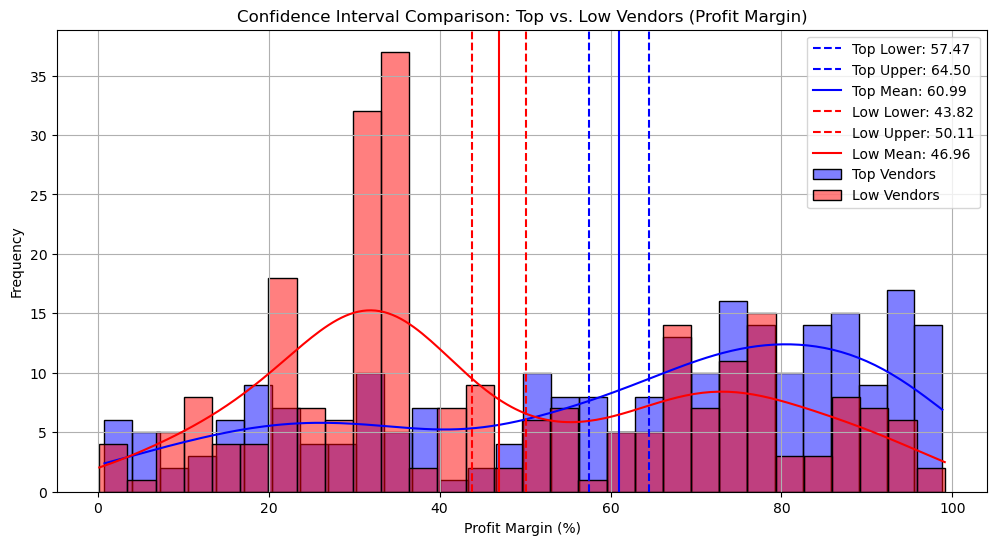

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

The average profit margin for top vendors is around 60.99%, while low-performing vendors have a lower average margin of about 46.96%, indicating that top vendors are generally more profitable.

The 95% confidence interval for top vendors (57.47% – 64.50%) is clearly higher than that of low vendors (43.82% – 50.11%), suggesting a consistent difference in profitability between the two groups.

Since the confidence intervals do not overlap, it indicates that the difference in profit margins between top and low vendors is statistically significant rather than due to random variation.

The distribution shows that top vendors are concentrated in higher profit margin ranges, whereas low vendors are more concentrated in lower margin ranges, reflecting differences in operational efficiency, pricing strategy, or product mix.

This suggests that high-performing vendors not only generate higher sales but also maintain stronger profit margins, making them key contributors to overall business profitability.

Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [50]:
from scipy.stats import ttest_ind

top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: 5.8581, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
